# HR Radar Observation Converter

This notebook inspects the `obs_seq` file created by the DART HF Radar converter.  
The converter itself should be run from the terminal. This notebook focuses on reading, summarizing, and visualizing the output observations.

## Objectives

In this notebook you will learn how to:

- Read a DART `obs_seq` file using pyDARTdiags
- Inspect observation types and metadata
- Learn the difference between total and radial velocity observations
- Understand the need for a forward operator and the extra metadata for the radial velocities
- Visualize observations on a map
- Compute basic observation statistics

## 1. Import Python libraries

In [152]:
import pydartdiags.obs_sequence.obs_sequence as obsq

import os
import cmocean
import numpy             as np
import pandas            as pd
import cartopy.crs       as ccrs
import cartopy.feature   as cfeature
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates

from pathlib              import Path
from IPython.display      import Markdown, display
from pydartdiags.stats    import stats
from pydartdiags.matplots import matplots as mp

## 2. Define paths

In [153]:
# Path to DART repo (directory) 
basedir = Path(f"/glade/derecho/scratch/{os.environ['USER']}/inacawo/DART_training")

# Path to the HFradar converter
hf_dir = basedir / 'observations' / 'obs_converters' / 'HFradar' 

# Path to the obs_seq file
obs_seq_file = hf_dir / 'work' / 'obs_seq.hf'
print(f"obs_seq file: {obs_seq_file}")

# Make sure the obs_Seq file exists
assert obs_seq_file.exists(), 'obs_seq file not found'

obs_seq file: /glade/derecho/scratch/gharamti/inacawo/DART_training/observations/obs_converters/HFradar/work/obs_seq.hf


## 3. Read and preview the obs_seq file

Notice the additional metadata that come in with the radial velocities. These describe the instrument ID and the bearing angle (in degrees) and they are used to build the forward operator, H(x), in our ensemble DA system.

Total velocities; i.e., U and V, on the other hand do not have any additional metadata. 

In [154]:
# Read the obs seq file into a DataFrame
obs = obsq.ObsSequence(obs_seq_file)

print(f"DataFrame shape: {obs.df.shape}")
print('\n')

display(obs.df)

DataFrame shape: (6471, 15)




,obs_num,observation,QC,linked_list,longitude,latitude,vertical,vert_unit,type,metadata,external_FO,seconds,days,time,obs_err_var
0,1,0.034060,0.0,-1 2 -1,105.983995,-5.922981,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 240.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002
1,2,0.004820,0.0,1 3 -1,105.982902,-5.920892,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 245.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002
2,3,-0.010770,0.0,2 4 -1,105.981996,-5.918716,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 250.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002
3,4,0.021980,0.0,3 5 -1,105.980772,-5.914170,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 260.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002
4,5,-0.029740,0.0,4 6 -1,105.980463,-5.911836,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 265.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6466,6467,0.094252,0.0,6466 6468 -1,105.980103,-5.896000,0.0,surface (m),HFRADAR_V_CURRENT_COMPONENT,[],[],14400,155141,2025-10-06 04:00:00,0.001523
6467,6468,0.017809,0.0,6467 6469 -1,105.980103,-5.886900,0.0,surface (m),HFRADAR_U_CURRENT_COMPONENT,[],[],14400,155141,2025-10-06 04:00:00,0.001085
6468,6469,0.157735,0.0,6468 6470 -1,105.980103,-5.886900,0.0,surface (m),HFRADAR_V_CURRENT_COMPONENT,[],[],14400,155141,2025-10-06 04:00:00,0.001273
6469,6470,0.126918,0.0,6469 6471 -1,105.980103,-5.877900,0.0,surface (m),HFRADAR_U_CURRENT_COMPONENT,[],[],14400,155141,2025-10-06 04:00:00,0.002483


## 4. Summarize the observation sequence

In [155]:
print("*" * 16)
print("obs_seq SUMMARY:")
print("*" * 16)

print(f"\nNumber of observations : {len(obs.df)}")
print(f"Number of obs types    : {len(obs.types)}")

# Available observation types in the obs_seq file 
# Each type is associated with a DART idenitifier number
print("\nObservation types:")
for kind, name in obs.types.items():
    print(f"  {kind:3d} : {name}")

# Number of copies in the obs_seq 
# observation, QC, .. could be more especially after assimilation 
print("\nObservation copies:")
for i, name in enumerate(obs.copie_names):
    print(f"  {i:2d} : {name}")

# Number of QCs
print("\nQC copies:")
for i, name in enumerate(obs.qc_copie_names):
    print(f"  {i:2d} : {name}")

display(
    obs.df["type"]
    .value_counts()
    .rename_axis("Observation Type")
    .to_frame("Count")
)

****************
obs_seq SUMMARY:
****************

Number of observations : 6471
Number of obs types    : 3

Observation types:
   61 : HFRADAR_U_CURRENT_COMPONENT
   62 : HFRADAR_V_CURRENT_COMPONENT
   63 : HFRADAR_RADIAL_VELOCITY

Observation copies:
   0 : observation
   1 : QC

QC copies:
   0 : QC


,Count
Observation Type,
HFRADAR_RADIAL_VELOCITY,3707
HFRADAR_U_CURRENT_COMPONENT,1382
HFRADAR_V_CURRENT_COMPONENT,1382


## 5. Visualize HF radar total velocity observations

The total velocity observations contain both eastward (`U`) and northward (`V`) current components.  
Unlike radial velocities, these can be plotted as full vectors using a quiver plot.

In [156]:
df = obs.df.copy()

# Total velocity observation types
u_type = "HFRADAR_U_CURRENT_COMPONENT"
v_type = "HFRADAR_V_CURRENT_COMPONENT"

df_u = df[df["type"] == u_type].copy()
df_v = df[df["type"] == v_type].copy()

# Merge U and V observations by time and location
df_totals = pd.merge(
    df_u,
    df_v,
    on=["time", "longitude", "latitude"],
    suffixes=("_u", "_v"),
)

df_totals = df_totals.rename(
    columns={
        "observation_u": "u",
        "observation_v": "v",
        "obs_err_var_u": "u_err_var",
        "obs_err_var_v": "v_err_var",
    }
)

# Compute the speed using both U and V
df_totals["speed"] = np.sqrt(df_totals["u"]**2 + df_totals["v"]**2)

print(f"Number of paired total velocity observations: {len(df_totals)}\n")

display(df_totals.head())

display(
    df_totals.groupby("time")
    .size()
    .rename("Number of total velocity vectors")
    .to_frame()
)

Number of paired total velocity observations: 1382



,obs_num_u,u,QC_u,linked_list_u,longitude,latitude,vertical_u,vert_unit_u,type_u,metadata_u,...,linked_list_v,vertical_v,vert_unit_v,type_v,metadata_v,external_FO_v,seconds_v,days_v,v_err_var,speed
0,3708,-0.049186,0.0,3707 3709 -1,105.808601,-5.9141,0.0,surface (m),HFRADAR_U_CURRENT_COMPONENT,[],...,3708 3710 -1,0.0,surface (m),HFRADAR_V_CURRENT_COMPONENT,[],[],11400,155141,0.050023,0.236606
1,3710,-0.003656,0.0,3709 3711 -1,105.808601,-5.9050,0.0,surface (m),HFRADAR_U_CURRENT_COMPONENT,[],...,3710 3712 -1,0.0,surface (m),HFRADAR_V_CURRENT_COMPONENT,[],[],11400,155141,0.057176,0.370180
2,3712,-0.134219,0.0,3711 3713 -1,105.817596,-5.9141,0.0,surface (m),HFRADAR_U_CURRENT_COMPONENT,[],...,3712 3714 -1,0.0,surface (m),HFRADAR_V_CURRENT_COMPONENT,[],[],11400,155141,0.031424,0.139823
3,3714,-0.116427,0.0,3713 3715 -1,105.817596,-5.9050,0.0,surface (m),HFRADAR_U_CURRENT_COMPONENT,[],...,3714 3716 -1,0.0,surface (m),HFRADAR_V_CURRENT_COMPONENT,[],[],11400,155141,0.041056,0.178517
4,3716,-0.195506,0.0,3715 3717 -1,105.826599,-5.9141,0.0,surface (m),HFRADAR_U_CURRENT_COMPONENT,[],...,3716 3718 -1,0.0,surface (m),HFRADAR_V_CURRENT_COMPONENT,[],[],11400,155141,0.040829,0.208085


,Number of total velocity vectors
time,
2025-10-06 03:10:00,195
2025-10-06 03:20:00,221
2025-10-06 03:30:00,229
2025-10-06 03:40:00,242
2025-10-06 03:50:00,246
2025-10-06 04:00:00,249


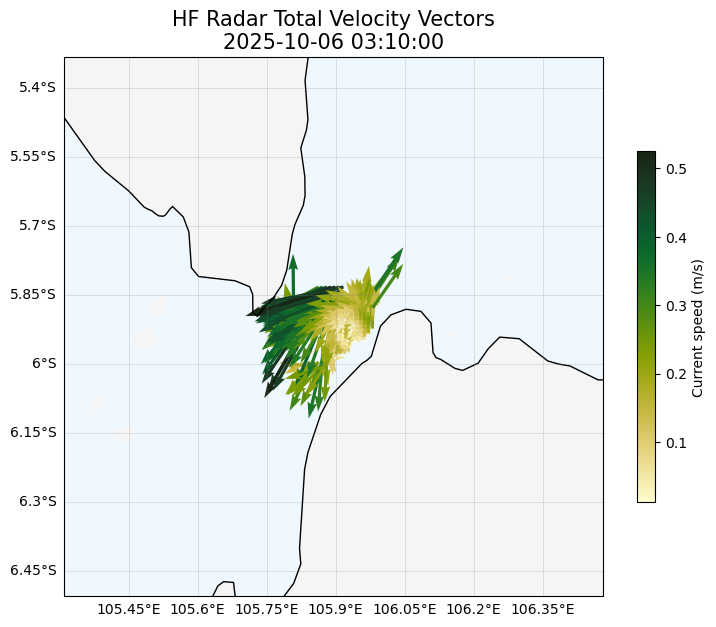


### Interpretation of Total Velocity Observations

HF radar total velocity observations provide both the eastward (U) and northward (V) components of the surface current. These observations therefore describe the full horizontal current vector at each observation location.

In the figure above, the arrows represent the observed surface current vectors, while the color indicates the current speed. Total velocity observations are typically derived by combining radial measurements from multiple radar stations and provide a direct estimate of the two-dimensional surface flow field.


In [167]:
# Select one time to plot
plot_time = sorted(df_totals["time"].unique())[0]

ob_sub = df_totals[df_totals["time"] == plot_time]

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=proj)

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

lon, lat = ob_sub['longitude'], ob_sub['latitude']
Uvel, Vvel, Uall = ob_sub['u'], ob_sub['v'], ob_sub['speed']

q = ax.quiver(lon, lat, Uvel, Vvel, Uall, 
    cmap=cmocean.cm.speed,
    transform=proj,
    scale=3, width=0.006,
)

plt.colorbar(q, ax=ax, label="Current speed (m/s)", shrink=0.65)

lon_min, lon_max = df_totals["longitude"].min(), df_totals["longitude"].max()
lat_min, lat_max = df_totals["latitude"].min() , df_totals["latitude"].max()

ax.set_extent(
    [lon_min - 0.5, lon_max + 0.5, lat_min - 0.5, lat_max + 0.5],
    crs=proj,
)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.3)
gl.top_labels = False
gl.right_labels = False

ax.set_title(f"HF Radar Total Velocity Vectors\n{plot_time}", fontsize=15)

plt.show()

display(Markdown("""
### Interpretation of Total Velocity Observations

HF radar total velocity observations provide both the eastward (U) and northward (V) components of the surface current. These observations therefore describe the full horizontal current vector at each observation location.

In the figure above, the arrows represent the observed surface current vectors, while the color indicates the current speed. Total velocity observations are typically derived by combining radial measurements from multiple radar stations and provide a direct estimate of the two-dimensional surface flow field.
"""))

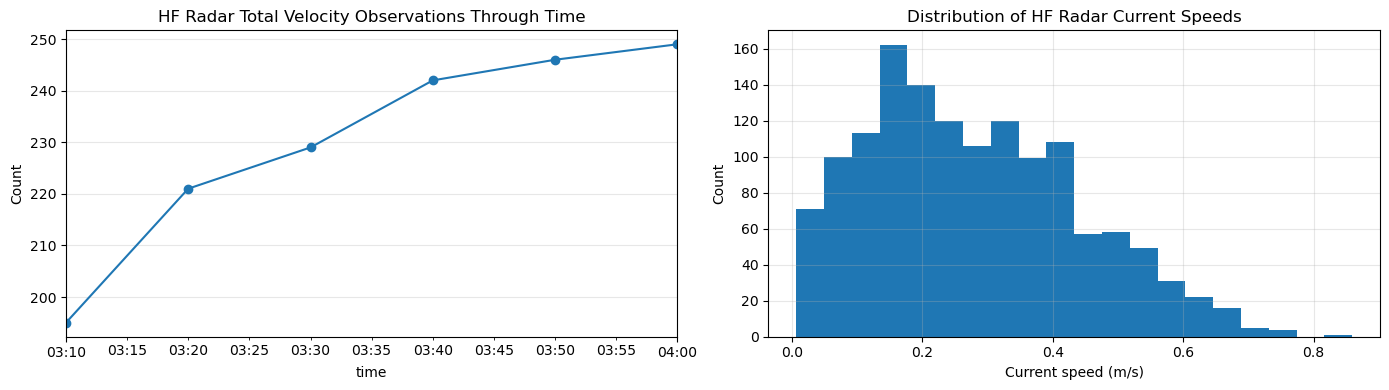

In [158]:
# Plot observation counts of the total velocity components over time
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
(df_totals.groupby("time")
          .size()
          .rename("Number of vectors")
          .plot(marker="o", ax=ax))
ax.set_ylabel("Count")
ax.set_title("HF Radar Total Velocity Observations Through Time")
ax.grid(alpha=0.3)

# Speed Histogram 
ax = axes[1]

ax.hist(df_totals["speed"], bins=20)
ax.set_xlabel("Current speed (m/s)")
ax.set_ylabel("Count")
ax.set_title("Distribution of HF Radar Current Speeds")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Visualize HF Radar Radial Velocity Observations

Unlike total velocity observations, radial observations only measure the
component of the current along the radar beam direction. They do not provide
the full two-dimensional current vector.

In [159]:
df_radial = df[df["type"] == "HFRADAR_RADIAL_VELOCITY"].copy()

print(f"Number of radial observations: {len(df_radial)}")

display(df_radial.head())

Number of radial observations: 3707


,obs_num,observation,QC,linked_list,longitude,latitude,vertical,vert_unit,type,metadata,external_FO,seconds,days,time,obs_err_var
0,1,0.03406,0.0,-1 2 -1,105.983995,-5.922981,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 240.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002
1,2,0.00482,0.0,1 3 -1,105.982902,-5.920892,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 245.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002
2,3,-0.01077,0.0,2 4 -1,105.981996,-5.918716,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 250.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002
3,4,0.02198,0.0,3 5 -1,105.980772,-5.914170,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 260.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002
4,5,-0.02974,0.0,4 6 -1,105.980463,-5.911836,0.0,surface (m),HFRADAR_RADIAL_VELOCITY,"[HFRADAR, InsID, 1361, angle, 265.000000000000...",[],600,155141,2025-10-06 00:10:00,0.026002


In [160]:
def parse_hfradar_metadata(meta):
    """
    Expected metadata form:
    [HFRADAR, InsID, 1361, angle, 265.0, ...]
    """
    out = {}

    for i, item in enumerate(meta):
        if item == "InsID":
            out["instrument_id"] = meta[i + 1]
        if item == "angle":
            out["bearing_angle"] = float(meta[i + 1])

    return out

meta = df_radial["metadata"].apply(parse_hfradar_metadata)

df_radial["instrument_id"] = meta.apply(lambda x: x.get("instrument_id"))
df_radial["bearing_angle"] = meta.apply(lambda x: x.get("bearing_angle"))

print("Radar site: BATU")
print(f"Location : {radar_lat:.3f}, {radar_lon:.3f}\n")

display(df_radial[["instrument_id", "bearing_angle", "longitude", "latitude", "observation"]].head())

Radar site: BATU
Location : -5.909, 106.007



,instrument_id,bearing_angle,longitude,latitude,observation
0,1361,240.0,105.983995,-5.922981,0.03406
1,1361,245.0,105.982902,-5.920892,0.00482
2,1361,250.0,105.981996,-5.918716,-0.01077
3,1361,260.0,105.980772,-5.914170,0.02198
4,1361,265.0,105.980463,-5.911836,-0.02974


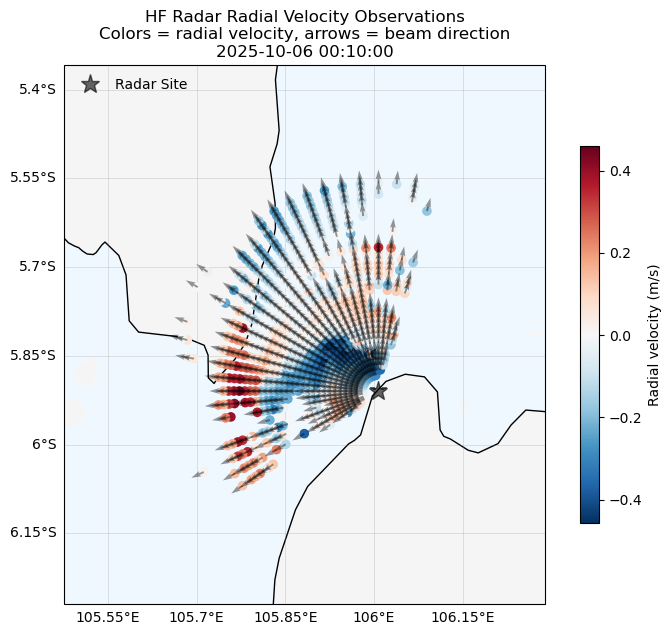


### Interpretation of Radial Velocity Observations
**Radar site:** BATU (-5.909°, 106.007°)

HF radar radial velocity observations measure only the component of the surface current along the radar beam direction. Unlike total velocity observations, a single radial measurement does not provide the full horizontal current vector.

In the figure above, the colored markers indicate the measured radial velocity, where positive values correspond to flow away from the radar and negative values correspond to flow toward the radar. The arrows show the radar beam directions associated with each observation and are included for visualization purposes only; they do not represent the ocean current direction.


In [169]:
# BATU radar site (global attributes of the raw netcdf files)
radar_lat = -5.9094833
radar_lon = 106.0075000

plot_time = sorted(df_radial["time"].unique())[0]
this_obs  = df_radial[df_radial["time"] == plot_time].copy()

lons, lats, data = this_obs['longitude'], this_obs['latitude'], this_obs['observation']

theta = np.deg2rad(this_obs["bearing_angle"])

# Bearing: degrees clockwise from true north
dx = np.sin(theta)
dy = np.cos(theta)

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9, 7))
ax = plt.axes(projection=proj)

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

sc = ax.scatter(lons, lats, c = data, 
    cmap='RdBu_r',
    s=35,
    transform=proj,
    zorder=4,
)

ax.quiver(lons, lats, dx, dy,  
    transform=proj,
    scale=35 , width=0.004,
    color="k", alpha=0.4, zorder=5,
)

plt.colorbar(sc, ax=ax, label="Radial velocity (m/s)", shrink=0.7)

lon_min, lon_max = lons.min(), lons.max()
lat_min, lat_max = lats.min(), lats.max()

ax.set_extent(
    [lon_min - 0.2, lon_max + 0.2, lat_min - 0.2, lat_max + 0.2],
    crs=proj,
)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color="gray", alpha=0.3)
gl.top_labels = False
gl.right_labels = False

ax.plot(radar_lon, radar_lat,
    marker="*", markersize=14,
    color="k", linestyle="None", alpha=0.6,
    transform=proj,
    label="Radar Site",
)

ax.legend(loc="upper left", frameon=False)

ax.set_title(
    f"HF Radar Radial Velocity Observations\n"
    f"Colors = radial velocity, arrows = beam direction\n"
    f"{plot_time}"
)

plt.show()

display(Markdown(f"""
### Interpretation of Radial Velocity Observations
**Radar site:** BATU ({radar_lat:.3f}°, {radar_lon:.3f}°)

HF radar radial velocity observations measure only the component of the surface current along the radar beam direction. Unlike total velocity observations, a single radial measurement does not provide the full horizontal current vector.

In the figure above, the colored markers indicate the measured radial velocity, where positive values correspond to flow away from the radar and negative values correspond to flow toward the radar. The arrows show the radar beam directions associated with each observation and are included for visualization purposes only; they do not represent the ocean current direction.
"""))

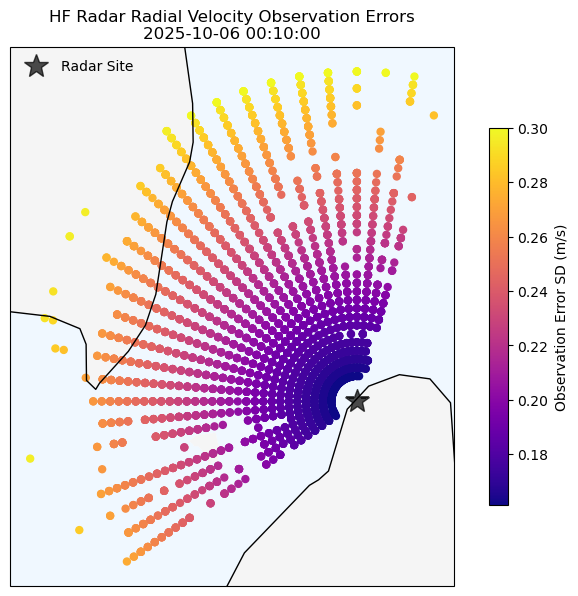


### Interpretation of Observation Errors

The observation error assigned to each radial velocity measurement increases with distance from the radar site. This reflects the reduced accuracy of HF radar measurements at longer ranges due to decreasing signal strength and increased uncertainty in the radial velocity estimates.

During data assimilation, observations with smaller assigned errors receive greater weight than observations with larger assigned errors.


In [170]:
# Display Range-Dependent Errors
df_radial["error_sd"] = np.sqrt(df_radial["obs_err_var"])

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,7))
ax = plt.axes(projection=proj)

ax.coastlines(resolution="10m")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")
ax.add_feature(cfeature.LAND, facecolor="whitesmoke")

vmin = df_radial["error_sd"].min()
vmax = df_radial["error_sd"].max()

sc = ax.scatter(
    df_radial["longitude"],
    df_radial["latitude"],
    c=df_radial["error_sd"],
    cmap="plasma",
    s=25, vmin=vmin, vmax=vmax, 
    transform=proj,
)

plt.colorbar(
    sc,
    ax=ax,
    label="Observation Error SD (m/s)",
    shrink=0.7,
)

ax.plot(
    radar_lon,
    radar_lat,
    marker="*",
    markersize=18,
    color="k", linestyle="None", alpha=0.7,
    transform=proj,
    label="Radar Site",
)

ax.legend(loc="upper left", frameon=False)

ax.set_title("HF Radar Radial Velocity Observation Errors\n"
            f"{plot_time}")

plt.show()

from IPython.display import Markdown, display

display(Markdown("""
### Interpretation of Observation Errors

The observation error assigned to each radial velocity measurement increases with distance from the radar site. This reflects the reduced accuracy of HF radar measurements at longer ranges due to decreasing signal strength and increased uncertainty in the radial velocity estimates.

During data assimilation, observations with smaller assigned errors receive greater weight than observations with larger assigned errors.
"""))

## 7. Observation Statistics

In [137]:
print("Observation time range:")
print(f"{df['time'].min()} to {df['time'].max()}")

print("\nLongitude range:")
print(f"{df['longitude'].min():.2f}° to {df['longitude'].max():.2f}°")

print("\nLatitude range:")
print(f"{df['latitude'].min():.2f}° to {df['latitude'].max():.2f}°")

summary = []

for obs_type in sorted(df["type"].unique()):

    this = df[df["type"] == obs_type]

    summary.append({
        "Type"          : obs_type,
        "Count"         : len(this),
        "Min"           : this["observation"].min().round(3),
        "Max"           : this["observation"].max().round(3),
        "Mean"          : this["observation"].mean().round(3),
        "Std"           : this["observation"].std().round(3),
        "Error SD" : np.sqrt(this["obs_err_var"]).mean().round(3),
    })

summary = pd.DataFrame(summary)

display(summary)

Observation time range:
2025-10-06 00:10:00 to 2025-10-06 04:00:00

Longitude range:
105.66° to 106.09°

Latitude range:
-6.08° to -5.56°


,Type,Count,Min,Max,Mean,Std,Error SD
0,HFRADAR_RADIAL_VELOCITY,3707,-0.515,0.460,-0.052,0.169,0.218
1,HFRADAR_U_CURRENT_COMPONENT,1382,-0.684,0.253,-0.158,0.169,0.030
2,HFRADAR_V_CURRENT_COMPONENT,1382,-0.768,0.370,-0.126,0.185,0.059


## Key Takeaways

- HF radar observations provide information about surface ocean currents.
- Total velocity observations contain both eastward (U) and northward (V) current components and therefore describe the full horizontal current vector.
- Radial velocity observations measure only the component of the current along the radar beam direction.
- Multiple radial observations from different radar stations can be combined to estimate total velocity fields.
- - Radial velocity observations require a forward operator that projects the model velocity vector onto the radar beam direction before comparison with observations.
- The observation locations, values, and assigned errors should always be inspected before assimilation.
- pyDARTdiags provides convenient tools for exploring and visualizing DART observation sequence files.